In [1]:
import numpy as np
import pandas as pd
import random
! pip install fastai==1.0.61
from fastai.tabular.transform import add_cyclic_datepart
from sklearn.model_selection import train_test_split
from sklearn import metrics

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.2/239.2 kB 4.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.9 MB/s eta 0:00:00:00:0100:01
  Created wheel for nvidia-ml-py3: filename=nvidia_ml_py3-7.352.0-py3-none-any.whl size=19172 sha256=a06b526d21df3d23700f2a37bd3a0b22b0dfff60bb8d2733fa9c377a904f48e9
  Stored in directory: /root/.cache/pip/wheels/47/50/9e/29dc79037d74

In [26]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Sampler
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import math
import random
from collections import defaultdict
import matplotlib.pyplot as plt

# 设置随机种子以确保可重复性
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")
# 数据加载和预处理
class YoochooseDataset:
    def __init__(self, data_dir="/kaggle/input/recsys-challenge-2015", sample_size=None):
        self.data_dir = data_dir
        self.sample_size = sample_size
        self.load_data()
        self.preprocess()
    
    def load_data(self):
        # 加载点击数据
        clicks_path = os.path.join(self.data_dir, "yoochoose-clicks.dat")
        self.clicks = pd.read_csv(clicks_path, sep=',', header=None, 
                                 names=["session", "timestamp", "item", "category"],
                                 dtype={'session': 'int32', 'item': 'int32', 'category': 'str'},
                                 parse_dates=['timestamp'])
        # 加载购买数据
        buys_path = os.path.join(self.data_dir, "yoochoose-buys.dat")
        self.buys = pd.read_csv(buys_path, sep=',', header=None, 
                               names=["session", "timestamp", "item", "price", "quantity"],
                               dtype={'session': 'int32', 'item': 'int32', 'price': 'int32', 'quantity': 'int8'},
                               parse_dates=['timestamp'])
        # 加载测试数据
        test_path = os.path.join(self.data_dir, "yoochoose-test.dat")
        self.test = pd.read_csv(test_path, sep=',', header=None, 
                               names=["session", "timestamp", "item", "category"],
                               dtype={'session': 'int32', 'item': 'int32', 'category': 'str'},
                               parse_dates=['timestamp'])
        # 如果指定了采样大小
        if self.sample_size:
            print(f"采样数据: {self.sample_size} 条会话")
            unique_sessions = self.clicks['session'].unique()
            sampled_sessions = np.random.choice(unique_sessions, min(self.sample_size, len(unique_sessions)), replace=False)
            self.clicks = self.clicks[self.clicks['session'].isin(sampled_sessions)]
    
    def preprocess(self):
        # 合并点击和购买数据
        self.clicks['is_buy'] = 0
        self.buys['is_buy'] = 1
        self.buys['category'] = '0'
        self.full_data = pd.concat([self.clicks[['session', 'timestamp', 'item', 'category', 'is_buy']], 
                                    self.buys[['session', 'timestamp', 'item', 'category', 'is_buy']]])
        self.full_data = self.full_data.sort_values(['session', 'timestamp'])
        
        # 项目编码
        self.item_encoder = LabelEncoder()
        self.full_data['item_idx'] = self.item_encoder.fit_transform(self.full_data['item'])
        self.n_items = len(self.item_encoder.classes_)
        
        # 类别编码
        self.category_encoder = LabelEncoder()
        self.full_data['category_idx'] = self.category_encoder.fit_transform(self.full_data['category'])
        
        # 创建会话序列
        self.session_sequences = self.full_data.groupby('session')['item_idx'].apply(list).to_dict()
        before_count = len(self.session_sequences)
        # 过滤长度小于 2 的会话
        self.session_sequences = {k: v for k, v in self.session_sequences.items() if len(v) >= 2}
        after_count = len(self.session_sequences)
        print(f"过滤前会话数: {before_count}, 过滤后会话数: {after_count}")
        
        # 调试：打印序列长度分布
        lengths = [len(seq) for seq in self.session_sequences.values()]
        print(f"序列长度分布: {pd.Series(lengths).value_counts().sort_index()}")
        # 划分训练集和测试集
        self.split_train_test()
    
    def split_train_test(self, test_size=0.2):
        """按时间划分训练集和测试集"""
        # 按时间排序会话
        session_times = self.full_data.groupby('session')['timestamp'].min()
        sorted_sessions = session_times.sort_values().index.tolist()
        
        # 划分训练集和测试集
        split_idx = int(len(sorted_sessions) * (1 - test_size))
        self.train_sessions = sorted_sessions[:split_idx]
        self.test_sessions = sorted_sessions[split_idx:]
        
        print(f"总会话数: {len(sorted_sessions)}")
        print(f"训练会话数: {len(self.train_sessions)}")
        print(f"测试会话数: {len(self.test_sessions)}")
        print(f"唯一项目数: {self.n_items}")

# 自定义数据集类
class SessionDataset(Dataset):
    def __init__(self, session_sequences, session_ids, n_items):
        self.session_sequences = session_sequences
        self.session_ids = session_ids
        self.n_items = n_items
    
    def __len__(self):
        return len(self.session_ids)
    
    def __getitem__(self, idx):
        session_id = self.session_ids[idx]
        sequence = self.session_sequences[session_id]
        
        # 输入是除最后一个项目外的所有项目
        inputs = sequence[:-1]
        # 目标是除第一个项目外的所有项目（用于训练）
        targets = sequence[1:]
        
        return {
            'inputs': torch.tensor(inputs, dtype=torch.long),
            'targets': torch.tensor(targets, dtype=torch.long),
            'length': len(inputs)
        }

# 自定义采样器 - 确保批次中的序列长度相似
class BucketSampler(Sampler):
    def __init__(self, data_source, batch_size=32, shuffle=True):
        self.data_source = data_source
        self.batch_size = batch_size
        self.shuffle = shuffle
        
        # 按长度分组
        self.lengths = [data_source[i]['length'] for i in range(len(data_source))]
        self.indices = list(range(len(data_source)))
        
        # 按序列长度排序
        self.indices.sort(key=lambda x: self.lengths[x])
        
        # 创建批次
        self.batches = []
        n_batches = math.ceil(len(self.indices) / batch_size)
        for i in range(n_batches):
            batch = self.indices[i*batch_size : (i+1)*batch_size]
            self.batches.append(batch)
        
        if shuffle:
            random.shuffle(self.batches)
    
    def __iter__(self):
        for batch in self.batches:
            yield batch
    
    def __len__(self):
        return len(self.batches)

# 自定义collate函数，用于处理批次数据
def session_collate_fn(batch):
    # 提取每个样本的数据
    inputs = [item['inputs'] for item in batch]
    targets = [item['targets'] for item in batch]
    lengths = [item['length'] for item in batch]
    
    # 对序列进行填充，使它们具有相同的长度
    max_length = max(lengths)
    padded_inputs = []
    padded_targets = []
    
    for inp, tgt, length in zip(inputs, targets, lengths):
        # 填充输入序列
        padding = torch.zeros(max_length - length, dtype=torch.long)
        padded_inp = torch.cat([inp, padding])
        padded_inputs.append(padded_inp)
        
        # 填充目标序列
        padded_tgt = torch.cat([tgt, padding])
        padded_targets.append(padded_tgt)
    
    # 转换为张量
    inputs_tensor = torch.stack(padded_inputs)
    targets_tensor = torch.stack(padded_targets)
    lengths_tensor = torch.tensor(lengths, dtype=torch.long)
    
    return {
        'inputs': inputs_tensor,
        'targets': targets_tensor,
        'length': lengths_tensor
    }

# GRU4Rec模型
class GRU4Rec(nn.Module):
    def __init__(self, n_items, embedding_dim=100, hidden_size=100, num_layers=1, dropout=0.1):
        super(GRU4Rec, self).__init__()
        self.n_items = n_items
        self.embedding_dim = embedding_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # 项目嵌入层
        self.item_embeddings = nn.Embedding(n_items, embedding_dim, padding_idx=0)
        # GRU层
        self.gru = nn.GRU(
            embedding_dim, 
            hidden_size, 
            num_layers, 
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        # 输出层
        self.output_layer = nn.Linear(hidden_size, n_items)
        # 初始化权重
        self._init_weights()
    
    def _init_weights(self):
        # 初始化嵌入层
        nn.init.normal_(self.item_embeddings.weight, 0, 0.01)
        # 初始化GRU层
        for name, param in self.gru.named_parameters():
            if 'weight' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
        
        # 初始化输出层
        nn.init.kaiming_normal_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)
    
    def forward(self, inputs, lengths, hidden=None):
        # 嵌入层
        embedded = self.item_embeddings(inputs)
        
        # 打包序列
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, 
            lengths.cpu(), 
            batch_first=True, 
            enforce_sorted=False
        )
        
        # GRU层
        packed_output, hidden = self.gru(packed, hidden)
        
        # 解包序列
        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_output, 
            batch_first=True, 
            total_length=inputs.size(1)
        )
        
        # 输出层
        output = self.output_layer(output)
        
        return output, hidden

# 训练函数
def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train()
    losses = []
    for epoch in range(num_epochs):
        total_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch in progress_bar:
            inputs = batch['inputs'].to(device)
            targets = batch['targets'].to(device)
            lengths = batch['length'].to(device)
            # 前向传播
            if len(lengths) == 0 or (lengths == 0).any():
                continue
            outputs, _ = model(inputs, lengths)
            # 计算损失 - 只考虑非填充位置
            loss = 0
            batch_size = inputs.size(0)
            for i in range(batch_size):
                # 获取实际序列长度
                seq_len = lengths[i]
                # 计算每个时间步的损失
                for t in range(seq_len):
                    # 目标项目
                    target_item = targets[i, t]
                    # 跳过填充位置
                    if target_item == 0:
                        continue
                    # 计算损失
                    loss += criterion(outputs[i, t].unsqueeze(0), target_item.unsqueeze(0))
            # 平均损失
            loss = loss / lengths.sum().float()
            # 反向传播和优化
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    return losses

# 评估函数 - 使用HR@20和MRR@20
def evaluate_model(model, test_loader, top_k=20):
    model.eval()
    total_hits = 0
    total_mrr = 0
    total_samples = 0
    with torch.no_grad():
        progress_bar = tqdm(test_loader, desc="评估中")
        for batch in progress_bar:
            inputs = batch['inputs'].to(device)
            targets = batch['targets'].to(device)
            lengths = batch['length'].to(device)
            # 前向传播
            if len(lengths) == 0 or (lengths == 0).any():
                continue
            outputs, _ = model(inputs, lengths)
            batch_size = inputs.size(0)
            for i in range(batch_size):
                # 获取实际序列长度
                seq_len = lengths[i]
                # 只考虑最后一个时间步的预测
                if seq_len == 0:
                    continue
                # 获取预测分数
                scores = outputs[i, seq_len-1]
                # 获取目标项目
                target_item = targets[i, seq_len-1].item()
                # 跳过填充位置
                if target_item == 0:
                    continue
                # 获取top-k预测
                _, top_indices = torch.topk(scores, top_k)
                top_items = top_indices.cpu().numpy()
                # 计算HR@k
                if target_item in top_items:
                    total_hits += 1
                    # 计算MRR@k
                    rank = np.where(top_items == target_item)[0][0] + 1
                    total_mrr += 1.0 / rank
                total_samples += 1
    hr = total_hits / total_samples
    mrr = total_mrr / total_samples
    return hr, mrr

使用设备: cuda


In [21]:
SAMPLE_SIZE = 100000  # 为了演示，使用较小的数据集
BATCH_SIZE = 64
HIDDEN_SIZE = 100
NUM_LAYERS = 1
DROPOUT = 0.2
EMBEDDING_DIM = 100
LEARNING_RATE = 0.001
NUM_EPOCHS = 5
TOP_K = 20
print("加载和预处理数据...")
dataset = YoochooseDataset(sample_size=SAMPLE_SIZE)

加载和预处理数据...
采样数据: 100000 条会话
过滤前会话数: 604229, 过滤后会话数: 361694
序列长度分布: 2      168445
3       77452
4       48239
5       22687
6       17119
        ...  
119         1
120         1
144         1
200         1
206         1
Name: count, Length: 91, dtype: int64
总会话数: 604229
训练会话数: 483383
测试会话数: 120846
唯一项目数: 25390


In [18]:
print("创建数据加载器...")
train_sampler = BucketSampler(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_sampler = BucketSampler(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_loader = DataLoader(
    train_dataset, 
    batch_sampler=train_sampler,  # 使用自定义的 BucketSampler
    collate_fn=session_collate_fn  # 使用自定义的 collate 函数
)
test_loader = DataLoader(
    test_dataset,
    batch_sampler=test_sampler,  # 使用自定义的 BucketSampler
    collate_fn=session_collate_fn  # 使用自定义的 collate 函数
)

创建数据加载器...


初始化模型...
模型参数: 5,163,990
开始训练...


Epoch 1/5: 100%|██████████| 7553/7553 [10:14<00:00, 12.29it/s, loss=5.09]  


Epoch 1/5, Loss: 3.8960


Epoch 2/5: 100%|██████████| 7553/7553 [10:12<00:00, 12.33it/s, loss=4.37]  


Epoch 2/5, Loss: 3.0489


...

Epoch 4/5: 100%|██████████| 7553/7553 [10:12<00:00, 12.33it/s, loss=3.95]  


Epoch 4/5, Loss: 2.6624


Epoch 5/5: 100%|██████████| 7553/7553 [10:12<00:00, 12.33it/s, loss=3.85]  


Epoch 5/5, Loss: 2.5514


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

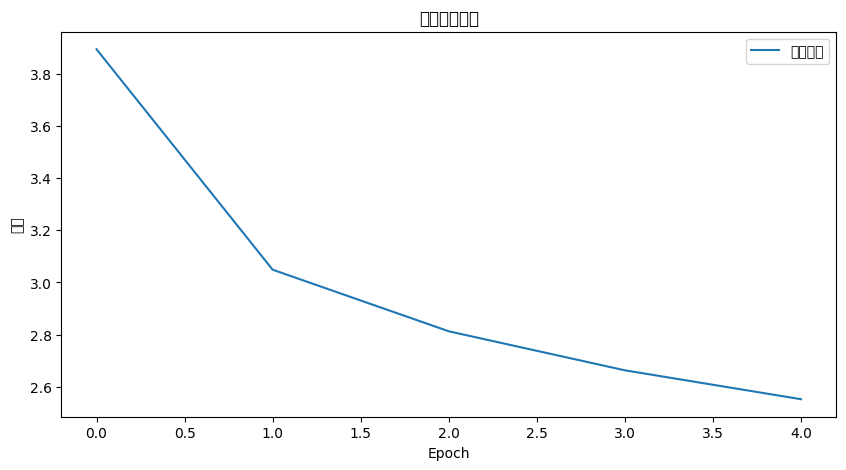

评估模型...


评估中:   0%|          | 0/1889 [00:00<?, ?it/s]


RuntimeError: Cannot pack empty tensors.

In [25]:
print("初始化模型...")
EMBEDDING_DIM = 100
LEARNING_RATE = 0.007
NUM_EPOCHS = 5
TOP_K = 20
model = GRU4Rec(
    n_items=dataset.n_items,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)
print(f"模型参数: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
# 损失函数和优化器
criterion = nn.CrossEntropyLoss(ignore_index=0)  # 忽略填充值
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print("开始训练...")
losses = train_model(model, train_loader, criterion, optimizer, NUM_EPOCHS)
# 绘制损失曲线
plt.figure(figsize=(10, 5))
plt.plot(losses, label='训练损失')
plt.xlabel('Epoch')
plt.ylabel('损失')
plt.title('训练损失曲线')
plt.legend()
plt.show()
print("评估模型...")
hr, mrr = evaluate_model(model, test_loader, TOP_K)
print(f"HR@{TOP_K}: {hr:.4f}")
print(f"MRR@{TOP_K}: {mrr:.4f}")
# 保存模型
torch.save(model.state_dict(), 'gru4rec_model.pth')
print("模型已保存")

In [27]:
print("评估模型...")
hr, mrr = evaluate_model(model, test_loader, TOP_K)
print(f"HR@{TOP_K}: {hr:.4f}")
print(f"MRR@{TOP_K}: {mrr:.4f}")
# 保存模型
torch.save(model.state_dict(), 'gru4rec_model.pth')
print("模型已保存")

评估模型...


评估中: 100%|██████████| 1889/1889 [00:29<00:00, 64.10it/s]

HR@20: 0.2476
MRR@20: 0.1234
模型已保存
